In [12]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from prophet import Prophet
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from math import sqrt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
import numpy as np
from datetime import datetime

Comparison between ARIMA, Prophet and XGboost for revenue forecasting

In [13]:
df = pd.read_csv("year_wise_sales.csv")   # columns: Financial Year, Month, Sales_data

# Month mapping
month_map = {
    "Apr":4, "May":5, "Jun":6, "Jul":7, "Aug":8, "Sep":9,
    "Oct":10, "Nov":11, "Dec":12, "Jan":1, "Feb":2, "Mar":3
}

In [14]:
def fy_month_to_date(row):
    fy = row["Financial Year"]
    start_year = int(fy.split("-")[0])

    # Convert month name directly to number (handles "April", "april", "APRIL")
    m = datetime.strptime(row["Month"].strip(), "%B").month

    # Financial year logic (Apr → Mar)
    year = start_year if m >= 4 else start_year + 1
    return pd.Timestamp(year=year, month=m, day=1)

# Apply transformation
df["ds"] = df.apply(fy_month_to_date, axis=1)
df = df.rename(columns={"Sales_data": "y"})
df = df[["ds", "y"]].sort_values("ds").reset_index(drop=True)

print(df.head())

          ds            y
0 2021-04-01  24083669.83
1 2021-05-01  26087855.93
2 2021-06-01  21933620.12
3 2021-07-01  31030293.32
4 2021-08-01  27179105.36


14:11:07 - cmdstanpy - INFO - Chain [1] start processing
14:11:08 - cmdstanpy - INFO - Chain [1] done processing


Prophet RMSE: 18423060.3850669 MAE: 14024344.816844702


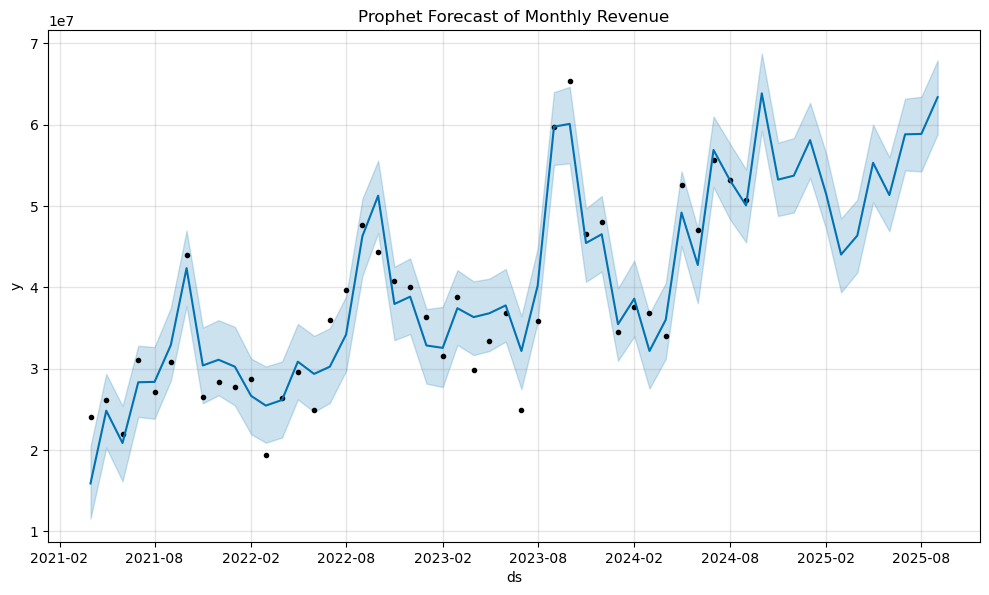

In [15]:
# --------------------------
# Prophet Forecast
# --------------------------
train = df.iloc[:-12]
test  = df.iloc[-12:]

m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(train)

future = m.make_future_dataframe(periods=12, freq="MS")
forecast = m.predict(future)

pred_test = forecast.set_index("ds").loc[test["ds"], "yhat"]
rmse = sqrt(mean_squared_error(test["y"], pred_test))
mae  = mean_absolute_error(test["y"], pred_test)
print("Prophet RMSE:", rmse, "MAE:", mae)

fig1 = m.plot(forecast)
plt.title("Prophet Forecast of Monthly Revenue")
plt.show()

In [17]:
# --------------------------
# ARIMA Forecast(non-seasonal)
# --------------------------
from statsmodels.tsa.arima.model import ARIMA

# Prepare train/test
train_y = train.set_index("ds")["y"]
test_y  = test.set_index("ds")["y"]

# Fit ARIMA model (p,d,q) - non-seasonal
# You can tune (p,d,q); here we start with (1,1,1)
arima_model = ARIMA(train_y, order=(1,1,1))
arima_res = arima_model.fit()

# Forecast on test set
arima_pred = arima_res.forecast(steps=len(test_y))
rmse_arima = sqrt(mean_squared_error(test_y, arima_pred))
mae_arima  = mean_absolute_error(test_y, arima_pred)
print("ARIMA RMSE:", rmse_arima, "MAE:", mae_arima)

# Forecast future 24 months
future_steps = 24
arima_future = arima_res.forecast(steps=future_steps)
future_index = pd.date_range(start=df["ds"].max() + pd.offsets.MonthBegin(1),
                             periods=future_steps, freq="MS")
future_forecast = pd.DataFrame({"ds": future_index,
                                "arima_forecast": arima_future.values})

ARIMA RMSE: 15352515.606691988 MAE: 13250125.559437057


c:\Users\Admin\anaconda3\envs\dppl_project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Admin\anaconda3\envs\dppl_project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Admin\anaconda3\envs\dppl_project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


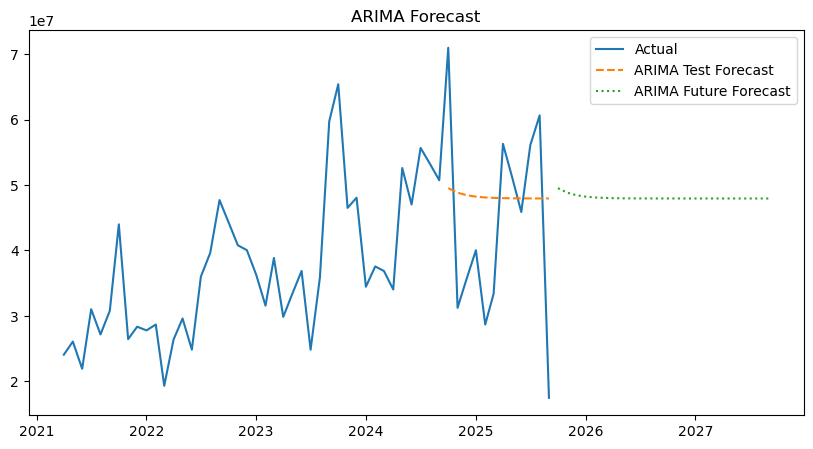

In [18]:
# Plot results
plt.figure(figsize=(10,5))
plt.plot(df["ds"], df["y"], label="Actual")
plt.plot(arima_pred.index, arima_pred, label="ARIMA Test Forecast", linestyle="--")
plt.plot(future_forecast["ds"], future_forecast["arima_forecast"], label="ARIMA Future Forecast", linestyle=":")
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

In [19]:
# --------------------------
# XGBoost Forecast
# --------------------------
df_xgb = df.copy()
df_xgb["y_lag1"] = df_xgb["y"].shift(1)
df_xgb["y_lag2"] = df_xgb["y"].shift(2)
df_xgb["rolling_mean3"] = df_xgb["y"].shift(1).rolling(window=3).mean()
df_xgb["month"] = df_xgb["ds"].dt.month
df_xgb = df_xgb.dropna()

X = df_xgb[["y_lag1","y_lag2","rolling_mean3","month"]]
y = df_xgb["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=12)

xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


XGBoost RMSE: 14821383.882806612 MAE: 11453382.908333333


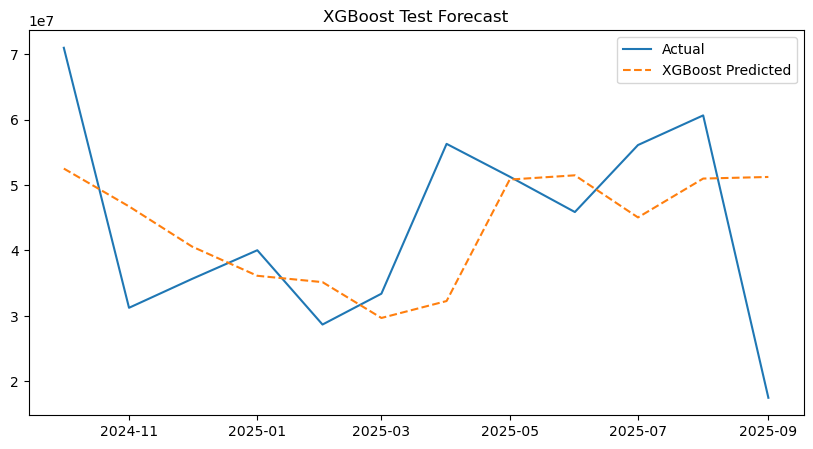

In [20]:
y_pred = xgb_model.predict(X_test)
rmse3 = sqrt(mean_squared_error(y_test, y_pred))
mae3  = mean_absolute_error(y_test, y_pred)
print("XGBoost RMSE:", rmse3, "MAE:", mae3)

# Plot predictions vs actual
plt.figure(figsize=(10,5))
plt.plot(df_xgb["ds"].iloc[-12:], y_test, label="Actual")
plt.plot(df_xgb["ds"].iloc[-12:], y_pred, label="XGBoost Predicted", linestyle="--")
plt.legend()
plt.title("XGBoost Test Forecast")
plt.show()

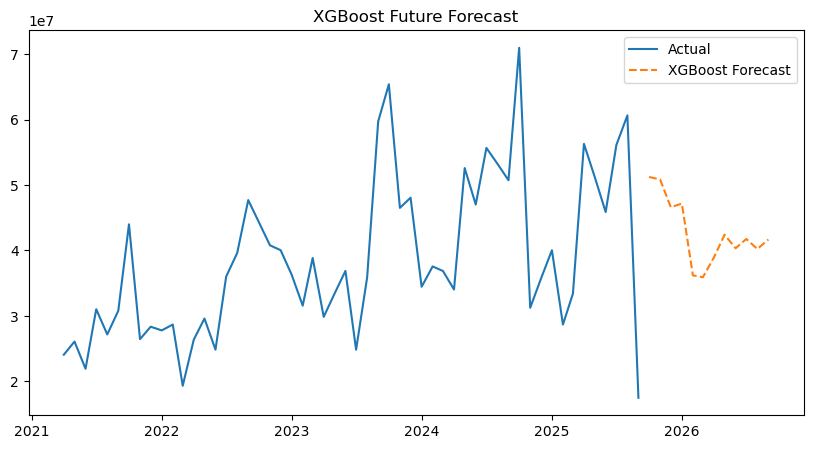

In [21]:
# Future forecasting using recursive prediction
future_preds = []
last_row = X.iloc[-1:].copy()

for i in range(12):  # forecast next 12 months
    pred_val = xgb_model.predict(last_row)[0]
    future_preds.append(pred_val)

    # shift lag features
    last_row["y_lag2"] = last_row["y_lag1"]
    last_row["y_lag1"] = pred_val
    last_row["rolling_mean3"] = (last_row["y_lag1"] + last_row["y_lag2"] + pred_val) / 3
    last_row["month"] = (last_row["month"] % 12) + 1

future_index = pd.date_range(start=df["ds"].max() + pd.offsets.MonthBegin(1),
                             periods=12, freq="MS")
xgb_forecast = pd.DataFrame({"ds":future_index, "xgb_forecast":future_preds})

plt.figure(figsize=(10,5))
plt.plot(df["ds"], df["y"], label="Actual")
plt.plot(xgb_forecast["ds"], xgb_forecast["xgb_forecast"], label="XGBoost Forecast", linestyle="--")
plt.legend()
plt.title("XGBoost Future Forecast")
plt.show()

In [23]:
# Create results directory
results_dir = "C:/Users/joshd/Documents/ML Project Sem-7/revenue_forecast_results"
os.makedirs(results_dir, exist_ok=True)

In [25]:
# Function to evaluate and save results
def evaluate_and_save(model_name, y_true, y_pred, dates):
    # Metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    # Save metrics to CSV
    metrics_df = pd.DataFrame({
        "Model": [model_name],
        "RMSE": [rmse],
        "MAE": [mae],
        "MAPE": [mape],
        "R2 Score": [r2]
    })
    metrics_path = os.path.join(results_dir, f"{model_name}_metrics.csv")
    metrics_df.to_csv(metrics_path, index=False)

    # Save predictions to CSV
    results_df = pd.DataFrame({
        "Date": dates,
        "Actual": y_true,
        "Predicted": y_pred
    })
    results_path = os.path.join(results_dir, f"{model_name}_predictions.csv")
    results_df.to_csv(results_path, index=False)

    # Plot and save
    plt.figure(figsize=(10, 6))
    plt.plot(dates, y_true, label="Actual", marker="o")
    plt.plot(dates, y_pred, label=f"{model_name} Predicted", marker="x")
    plt.title(f"{model_name} Forecast vs Actual")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plot_path = os.path.join(results_dir, f"{model_name}_forecast.png")
    plt.savefig(plot_path)
    plt.close()

    return metrics_df

In [26]:
# Dates for test period
dates_test = test["ds"]  # same for all models

# True revenue for test period
y_true_test = test["y"]

# Predictions from your models
y_pred_arima_test = arima_pred.values   # ARIMA test forecast
y_pred_prophet_test = pred_test.values  # Prophet test forecast
y_pred_xgb_test = y_pred                 # XGBoost test forecast

# Evaluate and save all
metrics_all = pd.DataFrame()
metrics_all = pd.concat([
    evaluate_and_save("ARIMA", y_true_test, y_pred_arima_test, dates_test),
    evaluate_and_save("Prophet", y_true_test, y_pred_prophet_test, dates_test),
    evaluate_and_save("XGBoost", y_true_test, y_pred_xgb_test, dates_test)
])

# Save combined metrics
metrics_all_path = os.path.join(results_dir, "C:/Users/joshd/Documents/ML Project Sem-7/all_models_forecast_metrics.csv")
metrics_all.to_csv(metrics_all_path, index=False)

print("All results saved in:", results_dir)

All results saved in: C:/Users/joshd/Documents/ML Project Sem-7/revenue_forecast_results


In [29]:
# Create results directory
results_dir = "C:/Users/joshd/Documents/ML Project Sem-7/future_revenue_forecast_results"
os.makedirs(results_dir, exist_ok=True)